In [1]:
'''
Given a data file to read, check Tally to see if any downstream packets went missing. This code
will not check if local packets were lost. This script was written to read 1 data file of
packets recorded from multiple tiles during QC testing for the v3a chip. The data file must have been
run from a configuration where tally was enabled
'''

###############################
# Imports
###############################

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from matplotlib.ticker import PercentFormatter, FixedFormatter, FixedLocator

###############################
# Initialize
###############################

#filename = "../data/packet-warm_ped_78kcycles_480s_2025_12_19_12_35_57_PST.h5"
#filename = "../data/packet-warm_ped_100kcycles_480s_2025_12_19.hdf5"
#filename = "../data/packet-warm_ped_150kcycles_480s_2025_12_22.hdf5"
#filename = "../data/packet-warm_ped_175kcycles_480s_7tile_2025_12_22.hdf5"
#filename = "../data/packet-warm_ped_150cycles_480s_7tiles_2025_12_22.hdf5"
#filename = "../data/packet-warm_ped_300kcycles_480s_7tile_2025_12_22.hdf5"
#filename = "../data/packet-warm_ped_400kcycles_480s_7tiles_2025_12_22.hdf5"
#filename = "../data/packet-warm_lin_t2_10kcycles_600s.hdf5"
#filename = "../data/packet-warm_lin_t2_file2_10kcycles_600s.hdf5"
#filename = "../data/packet-warm_lin_t2_150cycles_600s.hdf5"
filename = "../data/packet-warm_lin_t2_10kcycles_600s_9.7sramp.hdf5"

trig_cycles = "10k"

#filename = "../data/packet-warm_check_ext_trig_all_chan_1hz_120s_7tiles_2026_1_15.hdf5"
#filename = "../data/packet-warm_timing_200ns_120s_7tiles_2026_1_15.hdf5"
#filename = "../data/packet-warm_timing_200ns_120s_7tiles_2026_1_19.hdf5"
#filename = "../data/packet-warm_timing_300ns_120s_7tiles_2026_1_13.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
#tiles = [1,2,3,4,5,6,7]
tiles = [2]
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]

# if there are misnumbered chips you can s ee if they came from a chip that has low packet counts using
# the following pairing. List the legitimate chip_id first in this pair 
problem_chip_pair = [[],[161,225],[],[],[],[],[],[],[],[],[]]

# the number of clock ticks between periodic triggers (1E7 clock ticks = 1s)
periodic_trigger_cycles = 200000

# verbose = True will print out a detailed listing of the skipped tally counts for all chips 
verbose = False

# you can choose a particular chip to get more detailed information
verbose_tile = 2
verbose_chip = 16
verbose_chip_missing_counts = 0

# records tally by chip
tally = [[] for chp in range(256)]

# initialize variables
first_tile = True
unique_io_channels = []

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
                     ]
    
    return io_ch_per_tile[tile]

In [3]:
def get_data(filename):
    
    global unique_chips, tally, receipt_ts, bad_chip_count, missing, pkt_count, first_tile, unique_io_channels
    global problem_chip_pair, tiles, chip_serial_number_list, highest_ts
    
    # initialize at tile level
    npkts = 0
    first_problem_chip = True
    
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]

    # determine the time period for this data file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)

    # mask for sync packets (type 6) and external trigger (type 83)
    sync_mask = (packets['packet_type'] == 6) & (packets['trigger_type'] == 83)
    nsyncs = len(packets[sync_mask]) 

    if first_tile:

        first_tile = False
        
        # plot receipt timestamps before applying rollover
        data_mask     = packets['packet_type']  == 1
        data_pkts_before_rollover   = packets[data_mask]
        receipt_ts_before_rollover  = data_pkts_before_rollover['receipt_timestamp'][:]
    
        fig, ax = plt.subplots(1,2, figsize=(12, 3))
        ax[0].set_title(f'Receipt Timestamp Before Rollover (with {nsyncs} sync pkts)\nBenchtop test of v3a 10x16 tiles')
        ax[0].plot(receipt_ts_before_rollover)
        ax[0].set_xlabel("packet")
        ax[0].set_ylabel("Receipt Timestamp")  

        ax[1].set_title(f'Receipt Timestamp Before Rollover (with {nsyncs} sync pkts)\nBenchtop test of v3a 10x16 tiles')
        ax[1].hist(receipt_ts_before_rollover, bins=1000)
        ax[1].set_ylabel("# of Packets")
        ax[1].set_xlabel("Receipt Timestamp")  
        
        plt.show
    
#################################################################################################
# create a consistently increasing counting sequence from a saw-toothed series of 
# pacman counts (the "receipt_timestamp")
#################################################################################################

        # rollover will be used to adapt the saw-toothed time series to a consistently-increasing 
        # time series. Begin by creating an array of zeros the length of packets
        rollover = np.zeros((len(packets),), dtype='i8')
            
        # rollover_ticks is an array of the same size as rollover, but holds the value of the 
        # number of ticks in each pacman clock cycle (1E7)
        rollover_ticks = rollover + 1E7
    
        # mask for the sync signal (packet type 6) that's externally generated (trigger_type 83) 
        # to reset the pacman clock and set those elements of rollover to 1E7
        mask = (packets['packet_type'] == 6) & (packets['trigger_type'] == 83)
        rollover[mask] = rollover_ticks[mask]
            
        # Use cumsum to asign the value of 1E7 to each element of rollover, incrementing that 
        # amount by an additional 1E7 at each subsequent sync point
        rollover = np.cumsum(rollover)
            
        # add rollover to each packet's receipt_timestamp to create a consistently-increasing
        # clock sequence for this file
        ts = packets['receipt_timestamp'].astype('i8') + rollover
        pk_ts = packets['timestamp'].astype('i8') + rollover
    
        # sort the counting sequence and the packets by the "rolled over" receipt timestamp
        sorted_idcs = np.argsort(ts)
        sorted_ts = ts[sorted_idcs]
        sorted_pk_ts = pk_ts[sorted_idcs]
        sorted_pkts = packets[sorted_idcs]
        
        # create arrays of sorted data packets
        data_mask     = sorted_pkts['packet_type']  == 1
        data_pkts     = sorted_pkts[data_mask]
        receipt_ts    = sorted_ts[data_mask]
        pk_ts         = sorted_pk_ts[data_mask]
        npkts         = len(data_pkts)   
        
        print(f"{npkts:,} data packets were collected over {livetime} seconds (average data rate = {npkts/livetime:,.0f} pkts/s)")
    
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.set_title(f'Receipt Timestamp after Rollover (with {nsyncs} sync pkts)\nBenchtop test v3a 10x16 tiles')
        ax.plot(receipt_ts)
        ax.set_xlabel("packet")
        ax.set_ylabel("Receipt Timestamp")  
        plt.show

        # identify io_channels with data packets in this data file
        unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))

    for tile in tiles:
    
        print(f"\n\n############################ Checking Tile {tile} ###################################")
        print(f"Run Statistics:")
    
        # initialize for the tile
        missing   = np.zeros(256)
        pkt_count = np.zeros(256)
        unique_chips, chip_list, n_skip_list, n_tally_list = [], [], [], []
        bad_chip_count = 0
        
        # get a list of the io_channels that could be enabled for a given tile, and then determine which
        # ones were enabled
        io_channel_ids = get_io_channels(tile)
        enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
        
        # mask for the chosen tile
        tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
        tile_pkts = data_pkts[tile_mask]
        tile_ts   = receipt_ts[tile_mask]
        
        if len(tile_pkts) == 0: 
            print(f'There are no data packets for tile {tile}')        
            return
        
        print(f"\t{len(tile_pkts):,} data packets were collected from tile {tile}")
        
        unique_chips = list(dict.fromkeys(tile_pkts['chip_id'][:]))
        
    #######################################################################################
    # for each chip construct tally and call a function that counts missing packets
    #######################################################################################
        
        for chip in unique_chips:
            
            chip_mask = tile_pkts['chip_id']==chip
            chip_pkts = tile_pkts[chip_mask]
            chip_ts   = tile_ts[chip_mask]
            
            # tally records a sequential count (0-15) assigned to each packet as it enters its home shared FIFO
            # when tally is enabled, its value is stored in a combination of local and shared FIFO registers 
            fifo       = chip_pkts['shared_fifo']
            local_fifo = chip_pkts['local_fifo']
            tally[chip] = 4 * fifo + local_fifo 
            
            count_missing_pkts(tile, chip, tally[chip], chip_ts)
            
            if chip in range(11,171):
                chip_list.append(int(chip))
                n_skip_list.append(int(missing[chip]))
        
        print(f'\n{bad_chip_count} chips (out of {len(unique_chips)}) had at least 1 instance of skipping at least 1 tally in Tile {tile}')
    
        graph_missing(tile)
        
        if len(problem_chip_pair[tile]) > 0:
            combine_chips(problem_chip_pair[tile], tile, tile_pkts, tile_ts)
    
    return 

In [4]:
############################################################################################
# count the missing packets for a given chip using tally
############################################################################################
def count_missing_pkts(tile, chip, chip_tally, timestamps):
    
    global missing, pkt_count, bad_chip_count, problem_chip_pair, verbose_chip, verbose_tile, verbose_chip_missing_counts, highest_ts
    
    n_duplicates = 0
    
    pkt_count[chip] = len(chip_tally)
    
    if tile == verbose_tile and chip == verbose_chip:
        print(f"Missing for verbose chip {chip} begins at {missing[chip]} which has {len(chip_tally)} tallies")
    
    # tally counts from 0 to 15 then starts again at 0. Count instances of skipped tallies
    for i in range(len(chip_tally)-1):

        # check for instances of tally rolling over
        if chip_tally[i] > chip_tally[i+1]:
            missing[chip] += 15-chip_tally[i] + chip_tally[i+1]

        # check for instances of equal tallies.
        elif chip_tally[i] == chip_tally[i+1]:

            # If the timestamps are the same the chip fired twice (within 1 clock count, or 100ns)
            if timestamps[i+1] == timestamps[i]:
                n_duplicates +=1

            # if the timestamps are different some multiple of 16 tallies must have been skipped. We
            # can figure out how many were skipped by the difference in timestamps
            else:

                # the "int" function rounds down
                missing[chip] += int((timestamps[i+1] - timestamps[i]) / 1E7)
                
        else:
            missing[chip] += chip_tally[i+1] - chip_tally[i] - 1

    percent_missing = 100 * missing[chip]/pkt_count[chip]
    
    if missing[chip] > 0:
        bad_chip_count +=1
        print(f'\nChip {chip}: missing tally instances = {missing[chip]:.0f} (or {percent_missing}%)')
    
    if chip == verbose_chip and tile == verbose_tile:

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.set_title(f'Chip {verbose_chip} Tally\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax.plot(timestamps, chip_tally, marker='o')
        ax.set_xlabel("Packet Timestamp")
        ax.set_ylabel("Tally")
        plt.show 

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.set_title(f'Chip {verbose_chip} Tally[0:200]\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax.plot(timestamps[0:200], chip_tally[0:200], marker='o')
        ax.set_xlabel("Packet Timestamp")
        ax.set_ylabel("Tally")
        plt.show         
    
    return

In [5]:
def graph_missing(tile):

    global tally, missing, pkt_count, unique_chips, problem_chip_pair, trig_cycles
    
    missing_percent, missing_list, npkts_list = [],[],[]
    
    for chp in unique_chips:

        missing_percent.append( missing[chp] / pkt_count[chp] )
        missing_list.append(missing[chp])
        npkts_list.append(pkt_count[chp])

        if missing_percent[-1] > 0 and verbose and chp not in problem_chip_pair[tile]:
            
            print(f'\nChip {chp}: There were {missing[chp]} instances ({100*missing_percent[-1]:.1f}%) of skipping at least 1 Tally: Sample tally[0:20] =\n{tally[chp][0:20]}')

            fig, ax = plt.subplots(figsize=(16, 3))
            ax.set_title(f'Tile {tile} Chip {chp} Tally ({trig_cycles} peridic_trigger_cycle)\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
            ax.plot(tally[chp], marker='o')
            ax.set_xlabel("Packet Count Sorted by Receipt Timestamp")
            ax.set_ylabel("Tally") 
            plt.show

            fig, ax = plt.subplots(figsize=(10, 3))
            ax.set_title(f'Tile {tile} Chip {chp} Tally[0:200] ({trig_cycles} peridic_trigger_cycle)\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
            ax.plot(tally[chp][0:200], marker='o')
            ax.set_xlabel("Packet Count Sorted by Receipt Timestamp")
            ax.set_ylabel("Tally")
            plt.show
    
    mode_pkt_count_chip = mode(npkts_list)
    mode_missing_chip   = mode(missing_list)
    ratio_missing = 100 * mode_missing_chip / mode_pkt_count_chip

    print(f'\nmode(pkt count per chip) = {mode_pkt_count_chip:,.0f}\t mode(pkt loss per chip) = {mode_missing_chip:,.0f} (or {ratio_missing:.3f}%)')
    
    if sum(missing.tolist()) > 0:
        
        ymin = max(0, min(missing_percent) - 0.005)
        ymax = max(missing_percent) + 0.005
        
        fig, axis = plt.subplots(1,2, figsize=(12, 3))

        # Set fixed tick positions and labels
        positions = [0, .1, .25, .5, .75, 1]
        labels = ['0%', '10%', '25%', '50%', '75%', '100%'] 
        
        axis[0].set_title(f'% Instances of skip at least 1 Tally by Chip\n({trig_cycles} peridic_trigger_cycle), Benchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        axis[0].bar(unique_chips, missing_percent)
        axis[0].set_xlabel("Chip")
        axis[0].set_ylabel("Missing Percent (%)")
        axis[0].set_ylim( min(0,ymax) )
        axis[0].yaxis.set_major_locator(FixedLocator(positions))
        axis[0].yaxis.set_major_formatter(FixedFormatter(labels))

        ymin = max(0, min(missing) - 1)
        ymax = max(missing) + 1

        axis[1].set_title(f'# Instances of skipping at least 1 Tally by Chip\n({trig_cycles} peridic_trigger_cycle), Benchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        axis[1].bar(unique_chips, missing_list)
        axis[1].set_xlabel("Chip")
        axis[1].set_ylabel("Missing Count")
        #axis[1].set_ylim( min(0,ymax) )
        axis[1].set_yscale('log')
        plt.show
    
    return

In [6]:
def combine_chips(chip_pair, tile, tile_pkts, tile_ts):

    combined_tally, combined_ts = [], []
    sorted_missing = 0

    # combine packets and timestamps from the 2 identified chips
    for chip in chip_pair:
    
        chip_mask = tile_pkts['chip_id'] == chip
        chip_pkts = tile_pkts[chip_mask]
        chip_ts   = tile_ts[chip_mask]
        
        # tally records a sequential count (0-15) assigned to each packet as it enters its home shared FIFO
        # when tally is enabled, its value is stored in a combination of local and shared FIFO registers 
        fifo       = chip_pkts['shared_fifo']
        local_fifo = chip_pkts['local_fifo']
        tally = 4 * fifo + local_fifo 

        combined_tally.extend(tally)
        combined_ts.extend(chip_ts)
        
    # sort timestamps and tally by timestamps in order to check the combined tally
    sorted_pairs = sorted(zip(combined_ts, combined_tally))
    sorted_ts, sorted_tally = zip(*sorted_pairs)    

    # check the combined tally
    for i in range(len(sorted_tally)-2):
        if sorted_tally[i] == 15:
            if sorted_tally[i+1] !=0:
                sorted_missing +=1
        elif sorted_tally[i+1] != sorted_tally[i]+1:
            sorted_missing +=1
            if verbose: 
                try:
                    print(f'missing pkt for chip {chip}: skipped tally {tally[chip][i]} to {tally[chip][i+1]}')
                except:
                    print(f'problem with accessing tally for pkt {i+1} in tally in range {len(tally)}')
    
    print(f'\nA test was performed combining packets from {chip_pair[0]} and {chip_pair[1]} where the resulting # of missed tally instances = {sorted_missing}')   
    
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_title(f'Tally [0:200] from Combining Chips {chip_pair[0]} and {chip_pair[1]}\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
    ax.plot(sorted_tally[0:200], marker='o')
    ax.set_xlabel("Packet Count Sorted by Receipt Timestamp")
    ax.set_ylabel("Tally")
    plt.show    

    return


68,048,412 data packets were collected over 588 seconds (average data rate = 115,729 pkts/s)


############################ Checking Tile 2 ###################################
Run Statistics:
	68,048,412 data packets were collected from tile 2

Chip 120: missing tally instances = 146962 (or 34.71095071187658%)

Chip 75: missing tally instances = 144362 (or 33.82165858778492%)

Chip 27: missing tally instances = 146429 (or 34.294031818746035%)

Chip 119: missing tally instances = 140342 (or 33.16954420297562%)

Chip 20: missing tally instances = 143095 (or 33.44622705896652%)

Chip 133: missing tally instances = 147505 (or 34.73787336060458%)

Chip 90: missing tally instances = 129782 (or 30.58429285811916%)

Chip 109: missing tally instances = 141372 (or 33.315658868692864%)

Chip 111: missing tally instances = 134694 (or 31.92807211751571%)

Chip 147: missing tally instances = 135539 (or 32.04284704475015%)

Chip 23: missing tally instances = 140350 (or 32.89589334558384%)

Chip 106: 

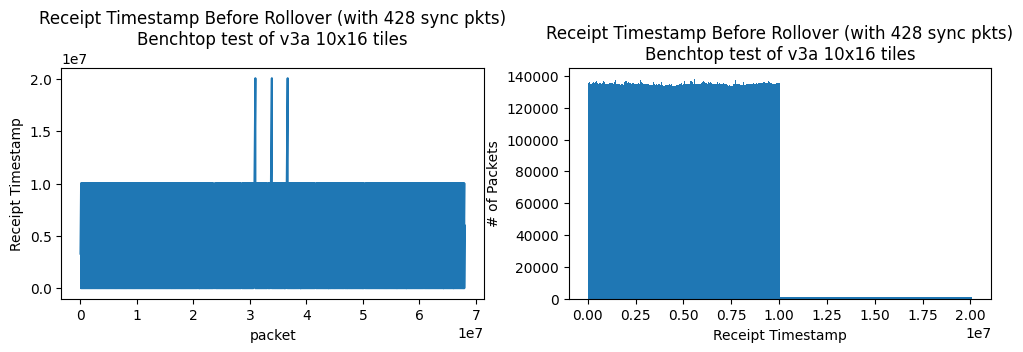

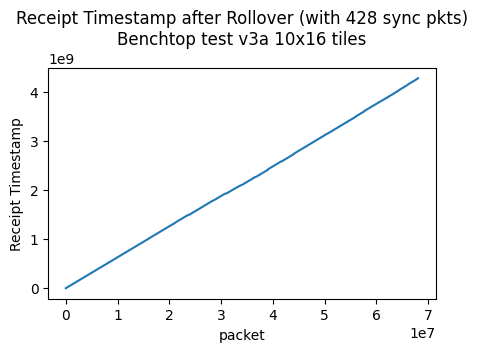

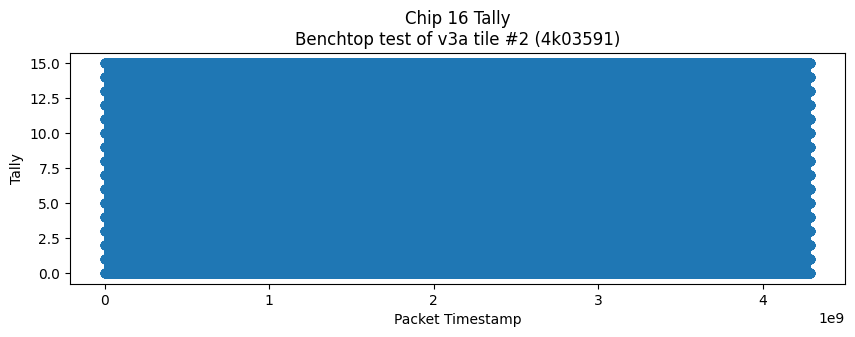

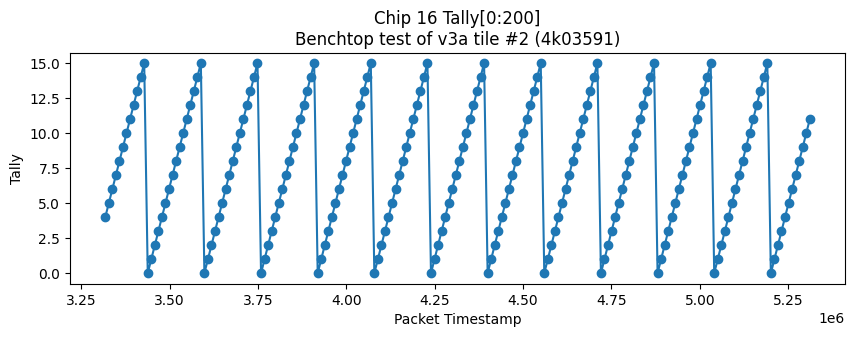

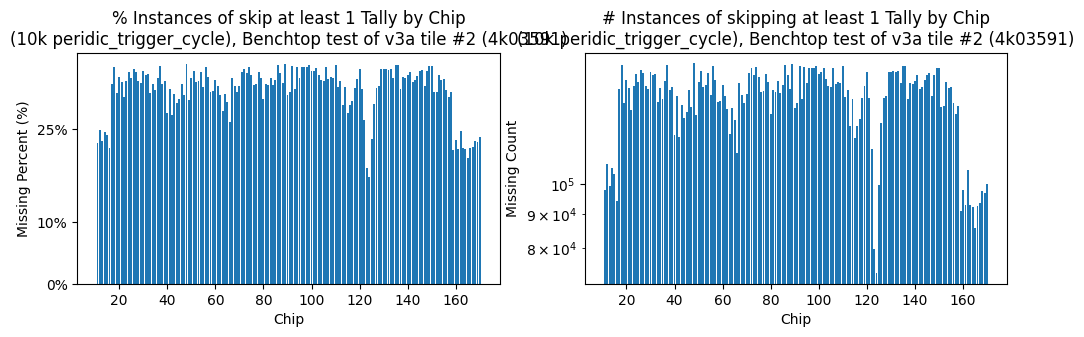

In [7]:
####################
# main
####################

get_data(filename)
